# Churn Risk Segmentation

## Objective
Assign every customer a risk score (High / Medium / Low)
based on the key churn drivers identified in Days 1 and 2.

## Risk Logic (based on findings)
- Contract type (Month-to-month = highest risk)
- Tenure cohort (0-12 months = highest risk)
- Internet service (Fiber optic = higher risk)

## Questions to Answer
- How many customers fall in each risk segment?
- What is the churn rate within each segment?
- What does a High Risk customer look like?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)

# Add tenure cohort
def tenure_cohort(tenure):
    if tenure <= 12:
        return '0-12 Months'
    elif tenure <= 24:
        return '13-24 Months'
    elif tenure <= 48:
        return '25-48 Months'
    else:
        return '49+ Months'

df['Tenure_Cohort'] = df['tenure'].apply(tenure_cohort)

print("Data loaded:", df.shape)

Data loaded: (7043, 23)


In [2]:
# Build Risk Score for each customer
def churn_risk_score(row):
    score = 0
    
    # Contract type (biggest driver)
    if row['Contract'] == 'Month-to-month':
        score += 3
    elif row['Contract'] == 'One year':
        score += 1
    # Two year = 0 points
    
    # Tenure cohort (second biggest driver)
    if row['Tenure_Cohort'] == '0-12 Months':
        score += 3
    elif row['Tenure_Cohort'] == '13-24 Months':
        score += 2
    elif row['Tenure_Cohort'] == '25-48 Months':
        score += 1
    # 49+ Months = 0 points
    
    # Internet service (third driver)
    if row['InternetService'] == 'Fiber optic':
        score += 2
    elif row['InternetService'] == 'DSL':
        score += 1
    # No internet = 0 points
    
    # No tech support adds risk
    if row['TechSupport'] == 'No':
        score += 1
        
    # Paperless billing adds slight risk
    if row['PaperlessBilling'] == 'Yes':
        score += 1
    
    return score

df['Risk_Score'] = df.apply(churn_risk_score, axis=1)

# Assign risk labels
def risk_label(score):
    if score >= 7:
        return 'High Risk'
    elif score >= 4:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['Risk_Segment'] = df['Risk_Score'].apply(risk_label)

# How many in each segment?
print("=== Risk Segment Distribution ===")
print(df['Risk_Segment'].value_counts())
print("\n=== As % of total ===")
print(df['Risk_Segment'].value_counts(normalize=True).round(2))

=== Risk Segment Distribution ===
Risk_Segment
High Risk      3132
Low Risk       2083
Medium Risk    1828
Name: count, dtype: int64

=== As % of total ===
Risk_Segment
High Risk      0.44
Low Risk       0.30
Medium Risk    0.26
Name: proportion, dtype: float64


=== Validation — Actual Churn Rate per Segment ===
              Churn_Rate  Customer_Count  Churn_Rate_Pct
Risk_Segment                                            
High Risk           0.49            3132            49.0
Medium Risk         0.15            1828            15.0
Low Risk            0.03            2083             3.0


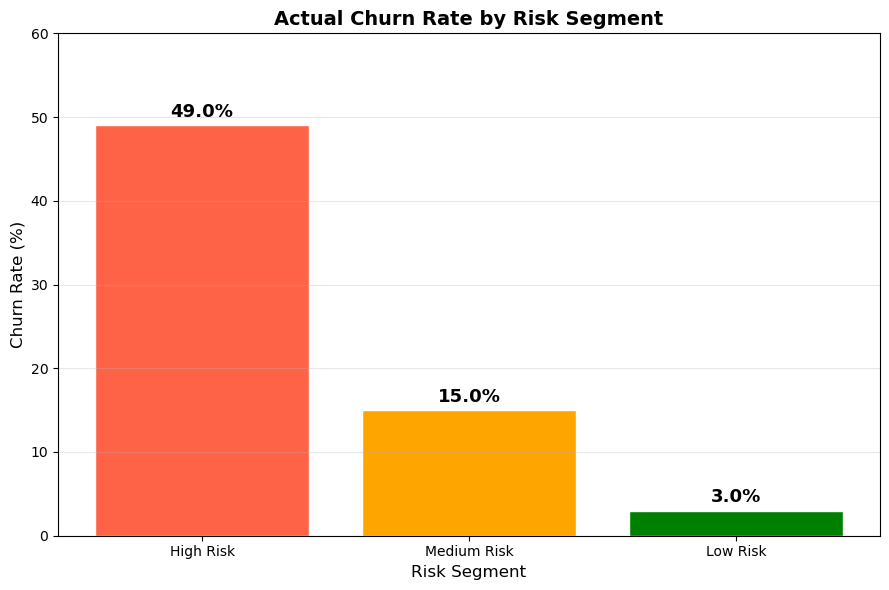

In [3]:
# Validate — does High Risk actually churn more?
validation = df.groupby('Risk_Segment')['Churn_Binary'].agg(['mean', 'count']).round(2)
validation.columns = ['Churn_Rate', 'Customer_Count']
validation = validation.reindex(['High Risk', 'Medium Risk', 'Low Risk'])
validation['Churn_Rate_Pct'] = (validation['Churn_Rate'] * 100).round(1)

print("=== Validation — Actual Churn Rate per Segment ===")
print(validation)

# Visualize
colors = ['tomato', 'orange', 'green']
plt.figure(figsize=(9, 6))
bars = plt.bar(validation.index, 
               validation['Churn_Rate_Pct'],
               color=colors, edgecolor='white')

for bar, val in zip(bars, validation['Churn_Rate_Pct']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val}%', ha='center', va='bottom', fontweight='bold', fontsize=13)

plt.title('Actual Churn Rate by Risk Segment', fontsize=14, fontweight='bold')
plt.xlabel('Risk Segment', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.ylim(0, 60)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Key Finding #5 — Risk Segmentation Validated

| Segment | Customers | Churn Rate |
|---|---|---|
| High Risk | 3,132 (44%) | 49% 🔴 |
| Medium Risk | 1,828 (26%) | 15% 🟡 |
| Low Risk | 2,083 (30%) | 3% ✅ |

**Validation:** Risk scores correctly predict churn behavior —
High Risk customers churn at 16x the rate of Low Risk customers.

**Business Recommendation:**
- Focus retention budget on 3,132 High Risk customers
- A 10% retention improvement in High Risk segment = ~153 customers saved
- Medium Risk customers need monitoring but lower urgency

In [4]:
# Export final scored dataset for dashboard
df_export = df[[
    'customerID', 'gender', 'SeniorCitizen', 'tenure',
    'Contract', 'InternetService', 'MonthlyCharges', 
    'TotalCharges', 'TechSupport', 'PaperlessBilling',
    'Tenure_Cohort', 'Risk_Score', 'Risk_Segment',
    'Churn', 'Churn_Binary'
]]

df_export.to_csv('../data/churn_scored.csv', index=False)
print("✅ Exported churn_scored.csv")
print("Shape:", df_export.shape)
print("\nRisk segment counts:")
print(df_export['Risk_Segment'].value_counts())

✅ Exported churn_scored.csv
Shape: (7043, 15)

Risk segment counts:
Risk_Segment
High Risk      3132
Low Risk       2083
Medium Risk    1828
Name: count, dtype: int64
